# 09 -- Model kosztow EW

Ten notebook przedstawia modele szacowania kosztow EW:

1. **Koszt urzadzen elektromechanicznych** -- wzor Ogayar & Vidal (2009)
2. **Koszt robot budowlanych** -- wskaznik do kosztu EM (IRENA)
3. **Koszt przylacza sieciowego** -- EUR/kW (NREL ATB)
4. **Koszty inzynierskie** -- % kosztow bezposrednich
5. **Koszty eksploatacji (O&M)** -- % inwestycji rocznie
6. **Przychody** -- cena energii i certyfikaty
7. **Metryki ekonomiczne** -- NPV, okres zwrotu, LCOE

Modele zaimplementowane w module `src/costs.py`.

---

## Zrodla danych

Model kosztow oparty na nastepujacych zrodlach:

| # | Zrodlo | Opis | Uzyte dane |
|---|--------|------|-----------|
| [1] | Ogayar B., Vidal P.G. (2009) "Cost determination of the electro-mechanical equipment of a small hydro-power plant." *Renewable Energy* 34(1):6-13. [doi:10.1016/j.renene.2008.04.039](https://doi.org/10.1016/j.renene.2008.04.039) | Wzory empiryczne kosztu EM dla turbin Pelton, Francis, Kaplan, semi-Kaplan. Dane z Hiszpanii, P<2MW. | Wspolczynniki a, b, c dla C=a*P^b*H^c |
| [2] | IRENA (2012) "Renewable Energy Technologies: Cost Analysis Series — Hydropower." Working Paper Vol.1 Issue 3/5. [PDF](https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2012/RE_Technologies_Cost_Analysis-HYDROPOWER.pdf) | Struktura kosztow: roboty budowlane, EM, przylacze. | Proporcje civil/EM wg typu elektrowni |
| [3] | IRENA (2024) "Renewable Power Generation Costs in 2023." ISBN 978-92-9260-587-2. [PDF](https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2024/Sep/IRENA_Renewable_power_generation_costs_in_2023.pdf) | Sredni koszt globalny USD 3053/kW (2023). LCOE USD 0.057/kWh. | Walidacja zakresu kosztow |
| [4] | NREL (2024) "Annual Technology Baseline — Hydropower." [Link](https://atb.nrel.gov/electricity/2024/hydropower) | NPD: $3045-20043/kW. Koszt przylacza $60-100/kW. | Koszt przylacza sieciowego |
| [5] | IEA (2021) "Hydropower Special Market Report." [PDF](https://iea.blob.core.windows.net/assets/83ff8935-62dd-4150-80a8-c5001b740e21/HydropowerSpecialMarketReport.pdf) | Koszty O&M 2-4% inwestycji rocznie. | Wskaznik O&M |
| [6] | Eurostat HICP [prc_hicp_aind] | Inflacja EU-27: 2009→2024 ≈ 37%. | Wskaznik inflacji 1.37 |
| [7] | URE (2024) Urzad Regulacji Energetyki, Polska. | Srednia cena energii z OZE ≈ PLN 490/MWh ≈ EUR 106.5/MWh. | Cena energii |

## Modul `src/costs.py`

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/costs.py do szacowania kosztow EW. Uzyj:
> (1) wzoru Ogayar & Vidal (2009) C_em = a*P^b*H^c dla kosztu EM,
> z wspolczynnikami dla Kaplan/Francis/Pelton/semi-Kaplan,
> z korektą inflacyjna 2009→2024 (czynnik 1.37).
> (2) kosztu robot budowlanych jako mnoznik kosztu EM (IRENA 2012).
> (3) kosztu przylacza EUR/kW (NREL ATB 2024).
> (4) kosztow inzynierskich jako % sumy.
> (5) O&M jako % inwestycji rocznie.
> (6) NPV, LCOE, okres zwrotu."*

**Funkcje w module:**
- `electromechanical_cost(P_kW, H, turbine_type)` -- koszt EM [EUR]
- `civil_works_cost(em_cost, plant_type)` -- roboty budowlane [EUR]
- `grid_connection_cost(P_kW, cost_per_kw)` -- przylacze [EUR]
- `engineering_cost(subtotal, fraction)` -- koszty inzynierskie [EUR]
- `total_investment(P_kW, H, n_turbines, ...)` -- pelny rozklad [dict]
- `annual_om_cost(investment, om_fraction)` -- O&M roczne [EUR]
- `annual_revenue(energy_mwh, price)` -- przychod roczny [EUR]
- `economic_analysis(energy, investment, ...)` -- NPV, LCOE, payback [dict]

## Konfiguracja

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.costs import (
    electromechanical_cost,
    civil_works_cost,
    grid_connection_cost,
    engineering_cost,
    total_investment,
    annual_om_cost,
    annual_revenue,
    economic_analysis,
    INFLATION_2009_TO_2024,
)

print(f'Modul zaladowany. Wskaznik inflacji 2009→2024: {INFLATION_2009_TO_2024}')

Modul zaladowany. Wskaznik inflacji 2009→2024: 1.37


---
## Krok 1: Koszt urzadzen elektromechanicznych

### Wzor Ogayar & Vidal (2009)

Empiryczny wzor kosztu EM (turbina + generator + regulator):

$$C_{EM} = a \cdot P^b \cdot H^c \quad [\text{EUR/kW, ceny 2009}]$$

gdzie $P$ w kW, $H$ w m. Wspolczynniki z Tabeli 3 w [1]:

| Typ turbiny | a | b | c | R² | Zakres |
|-------------|---|---|---|----|---------|
| Pelton | 17693 | -0.3644 | -0.2810 | 0.94 | P<2MW, H>50m |
| Francis | 25698 | -0.5600 | -0.1270 | 0.85 | P<2MW, H>10m |
| Kaplan | 33236 | -0.5800 | -0.1130 | 0.87 | P<2MW, H<20m |
| Semi-Kaplan | 19498 | -0.5800 | -0.1130 | 0.87 | P<2MW, H<20m |

**Korekta inflacyjna:** ceny 2009 × 1.37 = ceny 2024 (Eurostat HICP EU-27 [6]).

**Uwaga:** wzor walidowany dla P < 2 MW. Powyzej tej granicy formula *zanizyje*
koszty (rzeczywiste koszty sa WYZSZE — silna ekonomia skali Ogayara nie utrzymuje
sie dla duzych instalacji). Traktuj wynik dla P > 2 MW jako DOLNA granice kosztu.

**Prompt do LLM:**
> *"Narysuj koszt EM [EUR/kW] w funkcji mocy P (50-2000 kW) dla H=6m
> i H=50m, porownujac typy turbin. Pokaz efekt ekonomii skali."*

**Uzyte funkcje:** `src.costs.electromechanical_cost()`

In [2]:
P_range = np.linspace(50, 2000, 200)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['H = 6 m (niski spad)', 'H = 50 m (sredni spad)'])

types_low_H = [('kaplan', 'Kaplan', 'royalblue'), ('propeller', 'Smiglowa', 'green'),
               ('crossflow', 'Przeplywowa', 'darkorange')]
types_high_H = [('francis', 'Francis', 'firebrick'), ('pelton', 'Pelton', 'purple')]

for name, label, color in types_low_H:
    c_per_kw = [electromechanical_cost(P, 6.0, name) / P for P in P_range]
    fig.add_trace(go.Scatter(x=P_range, y=c_per_kw, mode='lines',
        name=label, line=dict(color=color, width=2)), row=1, col=1)

for name, label, color in types_high_H:
    c_per_kw = [electromechanical_cost(P, 50.0, name) / P for P in P_range]
    fig.add_trace(go.Scatter(x=P_range, y=c_per_kw, mode='lines',
        name=label, line=dict(color=color, width=2)), row=1, col=2)

fig.update_xaxes(title_text='P [kW]')
fig.update_yaxes(title_text='C_EM [EUR/kW]')
fig.update_layout(height=450, hovermode='x unified',
    title='Koszt EM wg wzoru Ogayar & Vidal (2009), ceny 2024')
fig.show()

# Walidacja: porownanie z danymi rynkowymi
print('Walidacja z danymi rynkowymi (europejscy dostawcy, 1-10MW):')
print(f'  Kaplan 500kW, H=6m:  EUR {electromechanical_cost(500, 6, "kaplan")/500:,.0f}/kW  (rynek ~740-1200 EUR/kW = 800-1300 USD/kW)')
print(f'  Francis 1MW, H=50m:  EUR {electromechanical_cost(1000, 50, "francis")/1000:,.0f}/kW  (rynek ~370-645 EUR/kW = 400-700 USD/kW)')

Walidacja z danymi rynkowymi (europejscy dostawcy, 1-10MW):
  Kaplan 500kW, H=6m:  EUR 1,012/kW  (rynek ~740-1200 EUR/kW = 800-1300 USD/kW)
  Francis 1MW, H=50m:  EUR 448/kW  (rynek ~370-645 EUR/kW = 400-700 USD/kW)


---
## Krok 2: Roboty budowlane

Koszt robot budowlanych wyraza sie jako mnoznik kosztu EM.
Wskaznik zalezy od typu elektrowni (dane z IRENA 2012 [2], 2023 [3]):

| Typ elektrowni | Stosunek civil/EM | Przyklad |
|----------------|------------------|----------|
| Przeplywowa mala (<5MW) | 0.8--1.2× | Mala EW na istniejacym stopniu |
| Przeplywowa duza (>5MW) | 1.5--3.0× | Duza EW z nowa zapora |
| Zapora zbiornikowa | 2.0--5.0× | Elektrownia ze zbiornikiem |
| Istniejaca zapora (retrofit) | 0.3--0.8× | Dobudowa turbiny do istn. zapory |

Dla **malych EW** (<5 MW) urzadzenia EM stanowia wieksza czesc kosztow
(40-50%), w przeciwienstwie do duzych elektrowni gdzie dominuja roboty
budowlane (65-75%).

In [3]:
# Porownanie typow elektrowni
em_base = electromechanical_cost(500, 6.0, 'kaplan')  # EUR

plant_types = [
    ('run_of_river_small', 'Przeplywowa mala'),
    ('run_of_river_large', 'Przeplywowa duza'),
    ('dam_reservoir', 'Zapora zbiornikowa'),
    ('existing_dam', 'Istniejaca zapora'),
]

print(f'Koszt EM (Kaplan 500kW, H=6m): EUR {em_base:,.0f}')
print()
for ptype, label in plant_types:
    civil = civil_works_cost(em_base, ptype)
    total = em_base + civil
    print(f'  {label:25s}: civil = EUR {civil:>10,.0f} ({civil/em_base:.1f}x EM), total EM+civil = EUR {total:,.0f}')

Koszt EM (Kaplan 500kW, H=6m): EUR 505,785

  Przeplywowa mala         : civil = EUR    505,785 (1.0x EM), total EM+civil = EUR 1,011,569
  Przeplywowa duza         : civil = EUR  1,011,569 (2.0x EM), total EM+civil = EUR 1,517,354
  Zapora zbiornikowa       : civil = EUR  1,770,246 (3.5x EM), total EM+civil = EUR 2,276,031
  Istniejaca zapora        : civil = EUR    252,892 (0.5x EM), total EM+civil = EUR 758,677


---
## Krok 3: Pelny rozklad kosztow inwestycji

Calkowity koszt inwestycji:

$$I = C_{EM} + C_{civil} + C_{grid} + C_{eng}$$

gdzie:
- $C_{EM}$ -- urzadzenia EM: Ogayar & Vidal (2009) [1]
- $C_{civil}$ -- roboty budowlane: mnoznik × $C_{EM}$ [2,3]
- $C_{grid}$ -- przylacze sieciowe: EUR 100/kW [4]
- $C_{eng}$ -- inzynieria, projekty, pozwolenia: 10% sumy [2]

**Prompt do LLM:**
> *"Oblicz pelny rozklad kosztow dla 4 wariantow: Kaplan 1×500kW,
> 2×250kW, 4×125kW, i 1×2000kW, przy H=6m, typ run-of-river small.
> Pokaz tabelke i wykres slupkowy rozkladu."*

**Uzyte funkcje:** `src.costs.total_investment()`

In [4]:
H = 6.0
variants = [
    ('1 × 500 kW', 500, 1),
    ('2 × 250 kW', 250, 2),
    ('4 × 125 kW', 125, 4),
    ('1 × 2000 kW', 2000, 1),
]

rows = []
for label, P, n in variants:
    inv = total_investment(P, H, n, turbine_type='kaplan', plant_type='run_of_river_small')
    rows.append({
        'Wariant': label,
        'P total [kW]': inv['P_total_kW'],
        'EM [kEUR]': round(inv['em_eur'] / 1000),
        'Civil [kEUR]': round(inv['civil_eur'] / 1000),
        'Grid [kEUR]': round(inv['grid_eur'] / 1000),
        'Eng [kEUR]': round(inv['engineering_eur'] / 1000),
        'Total [kEUR]': round(inv['total_eur'] / 1000),
        'EUR/kW': round(inv['total_per_kw_eur']),
    })

df_inv = pd.DataFrame(rows)
print('Rozklad kosztow inwestycji (Kaplan, H=6m):')
df_inv

Rozklad kosztow inwestycji (Kaplan, H=6m):


,Wariant,P total [kW],EM [kEUR],Civil [kEUR],Grid [kEUR],Eng [kEUR],Total [kEUR],EUR/kW
0,1 × 500 kW,500,506,506,50,106,1168,2335
1,2 × 250 kW,500,756,756,50,156,1718,3437
2,4 × 125 kW,500,1130,1130,50,231,2541,5083
3,1 × 2000 kW,2000,905,905,200,201,2212,1106


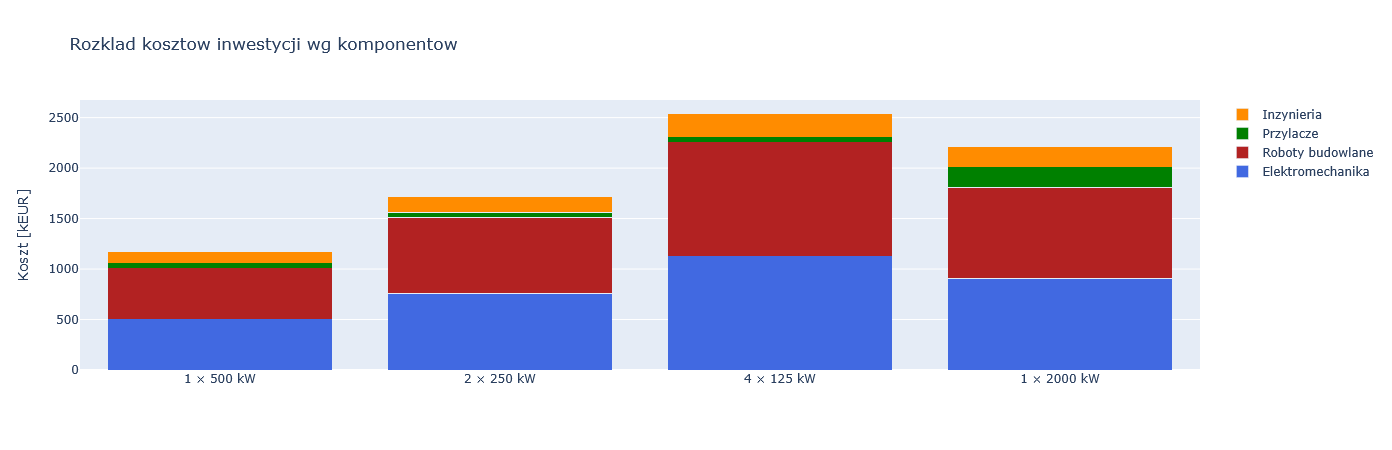

In [5]:
# Wykres slupkowy rozkladu
fig = go.Figure()
components = ['EM [kEUR]', 'Civil [kEUR]', 'Grid [kEUR]', 'Eng [kEUR]']
colors = ['royalblue', 'firebrick', 'green', 'darkorange']
names = ['Elektromechanika', 'Roboty budowlane', 'Przylacze', 'Inzynieria']

for comp, color, name in zip(components, colors, names):
    fig.add_trace(go.Bar(
        x=df_inv['Wariant'], y=df_inv[comp],
        name=name, marker_color=color,
    ))

fig.update_layout(
    title='Rozklad kosztow inwestycji wg komponentow',
    yaxis_title='Koszt [kEUR]',
    barmode='stack', height=450,
)
fig.show()

---
## Krok 4: Efekt skali i porownanie typow turbin

Koszt jednostkowy [EUR/kW] maleje ze wzrostem mocy (ekonomia skali).
Rozne typy turbin maja rozne koszty dla tych samych parametrow.

D:\dydaktyka\2025_2026\EW\notebooks\..\src\costs.py:259: UserWarning: Ogayar & Vidal (2009) validated for P<2 MW; extrapolating to P=2021 kW. Result likely biased low (the formula assumes a single curve; large plants actually benefit from extra economies of scale not captured here).
  em_per_unit = electromechanical_cost(P_kW, H, turbine_type, inflation_factor)
D:\dydaktyka\2025_2026\EW\notebooks\..\src\costs.py:259: UserWarning: Ogayar & Vidal (2009) validated for P<2 MW; extrapolating to P=2045 kW. Result likely biased low (the formula assumes a single curve; large plants actually benefit from extra economies of scale not captured here).
  em_per_unit = electromechanical_cost(P_kW, H, turbine_type, inflation_factor)
D:\dydaktyka\2025_2026\EW\notebooks\..\src\costs.py:259: UserWarning: Ogayar & Vidal (2009) validated for P<2 MW; extrapolating to P=2070 kW. Result likely biased low (the formula assumes a single curve; large plants actually benefit from extra economies of scale not capt

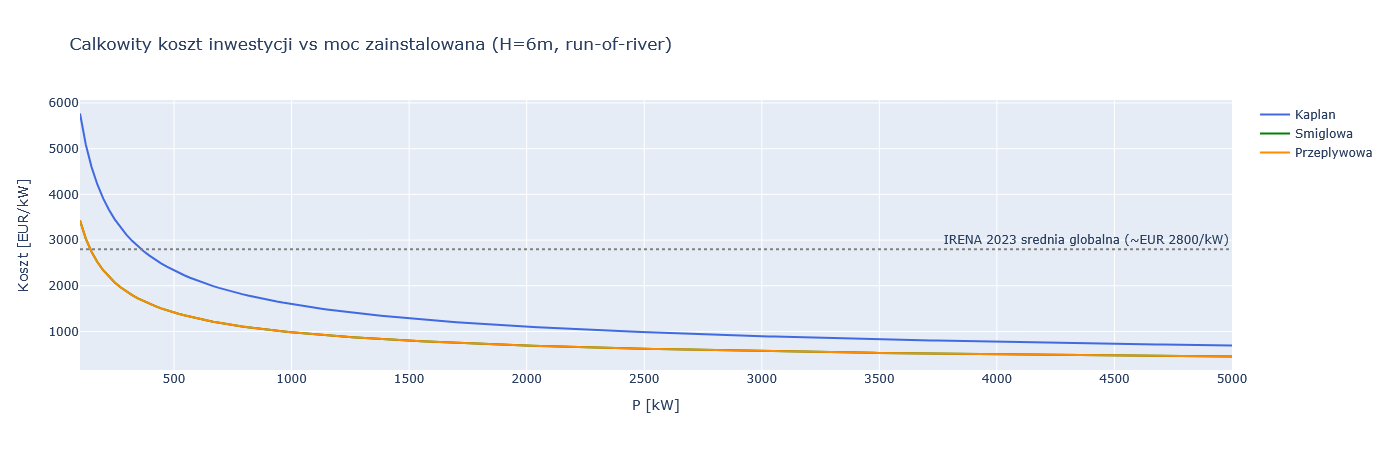

In [6]:
P_range = np.linspace(100, 5000, 200)

fig = go.Figure()
for ttype, label, color in [('kaplan', 'Kaplan', 'royalblue'),
                             ('propeller', 'Smiglowa', 'green'),
                             ('crossflow', 'Przeplywowa', 'darkorange')]:
    costs = [total_investment(P, 6.0, 1, ttype, 'run_of_river_small')['total_per_kw_eur']
             for P in P_range]
    fig.add_trace(go.Scatter(x=P_range, y=costs, mode='lines',
        name=label, line=dict(color=color, width=2)))

# Dodaj zakres IRENA 2023
fig.add_hline(y=2800, line_dash='dot', line_color='gray',
    annotation_text='IRENA 2023 srednia globalna (~EUR 2800/kW)')

fig.update_layout(
    title='Calkowity koszt inwestycji vs moc zainstalowana (H=6m, run-of-river)',
    xaxis_title='P [kW]', yaxis_title='Koszt [EUR/kW]',
    height=450, hovermode='x unified',
)
fig.show()

---
## Krok 5: Analiza ekonomiczna

### Metryki

**Prosty okres zwrotu:**
$$T_{payback} = \frac{I}{R_{net}} = \frac{I}{R - C_{O\&M}}$$

**NPV (wartosc biezaca netto):** przy stalym rocznym dochodzie netto:
$$NPV = -I + R_{net} \cdot \frac{1 - (1+r)^{-T}}{r}$$

**LCOE (sredni koszt energii):**
$$LCOE = \frac{I \cdot CRF + C_{O\&M}}{E} \quad [\text{EUR/MWh}]$$
$$CRF = \frac{r \cdot (1+r)^T}{(1+r)^T - 1}$$

### Parametry domyslne

| Parametr | Wartosc | Zrodlo |
|----------|---------|--------|
| Cena energii | EUR 106.5/MWh (PLN 490/MWh) | URE 2024 [7] |
| O&M | 2.5% inwestycji/rok | IRENA 2012 [2], IEA 2021 [5] |
| Stopa dyskontowa | 6% | Typowa dla OZE w UE |
| Czas zycia | 40 lat | Standard dla hydroenergetyki |

**Prompt do LLM:**
> *"Oblicz analize ekonomiczna dla EW Kaplan 4×500kW, H=6m,
> produkcja 3500 MWh/rok. Pokaz rozklad przychodow i kosztow,
> skumulowany cashflow przez 40 lat."*

**Uzyte funkcje:** `total_investment()`, `economic_analysis()`

In [7]:
# Przykladowa analiza
inv = total_investment(500, 6.0, n_turbines=4, turbine_type='kaplan',
                       plant_type='run_of_river_small')
econ = economic_analysis(
    energy_mwh=3500,
    investment_eur=inv['total_eur'],
    energy_price_eur_mwh=106.5,
    om_fraction=0.025,
    discount_rate=0.06,
    lifetime_years=40,
)

print(f'=== Analiza ekonomiczna: Kaplan 4×500kW, H=6m ===')
print(f'  Inwestycja:         EUR {inv["total_eur"]:>12,.0f}  ({inv["total_per_kw_eur"]:,.0f} EUR/kW)')
print(f'  Produkcja:          {3500:>12,} MWh/rok')
print(f'  Przychod roczny:    EUR {econ["annual_revenue_eur"]:>12,.0f}')
print(f'  O&M roczne:         EUR {econ["annual_om_eur"]:>12,.0f}')
print(f'  Dochod netto:       EUR {econ["net_annual_eur"]:>12,.0f}')
print(f'  ---')
print(f'  Okres zwrotu:       {econ["payback_years"]:>12.1f} lat')
print(f'  NPV (r=6%, T=40):  EUR {econ["npv_eur"]:>12,.0f}')
print(f'  LCOE:               EUR {econ["lcoe_eur_mwh"]:>12.1f}/MWh')

=== Analiza ekonomiczna: Kaplan 4×500kW, H=6m ===
  Inwestycja:         EUR    4,670,905  (2,335 EUR/kW)
  Produkcja:                 3,500 MWh/rok
  Przychod roczny:    EUR      372,750
  O&M roczne:         EUR      116,773
  Dochod netto:       EUR      255,977
  ---
  Okres zwrotu:               18.2 lat
  NPV (r=6%, T=40):  EUR     -819,393
  LCOE:               EUR        122.1/MWh


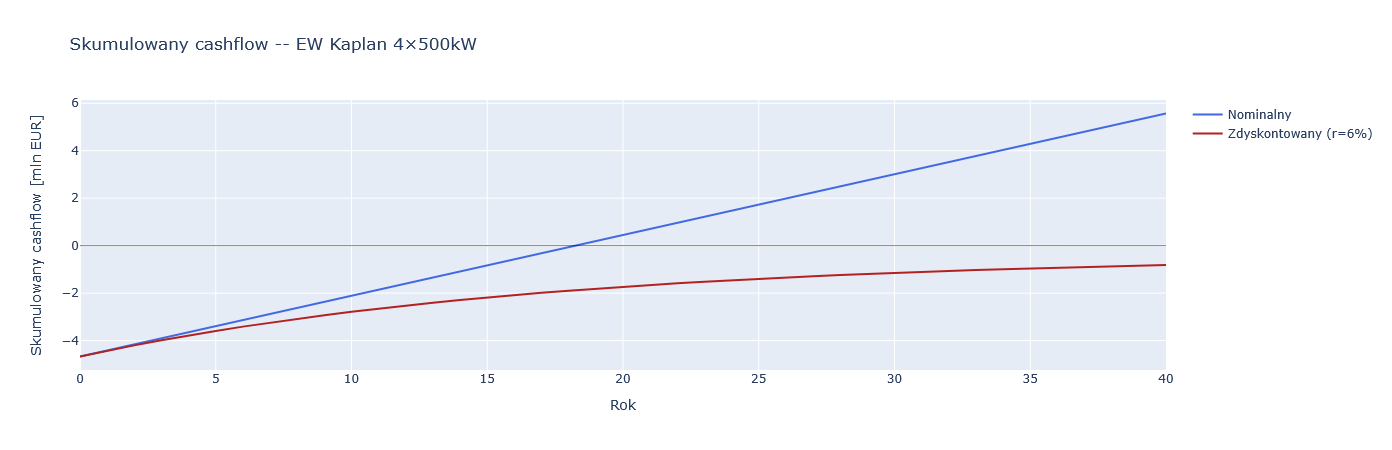

In [8]:
# Skumulowany cashflow
years = np.arange(0, 41)
cashflow_simple = np.concatenate([[-inv['total_eur']],
    np.full(40, econ['net_annual_eur'])])
cumulative = np.cumsum(cashflow_simple)

# Zdyskontowany
r = 0.06
dcf = np.concatenate([[-inv['total_eur']],
    [econ['net_annual_eur'] / (1 + r)**t for t in range(1, 41)]])
cumulative_dcf = np.cumsum(dcf)

fig = go.Figure()
fig.add_trace(go.Scatter(x=years, y=cumulative / 1e6, mode='lines',
    name='Nominalny', line=dict(color='royalblue', width=2)))
fig.add_trace(go.Scatter(x=years, y=cumulative_dcf / 1e6, mode='lines',
    name='Zdyskontowany (r=6%)', line=dict(color='firebrick', width=2)))
fig.add_hline(y=0, line_color='black', line_width=0.5)

fig.update_layout(
    title='Skumulowany cashflow -- EW Kaplan 4×500kW',
    xaxis_title='Rok', yaxis_title='Skumulowany cashflow [mln EUR]',
    height=450, hovermode='x unified',
)
fig.show()

---
## Krok 6: Analiza wrazliwosci

Jak zmienia sie NPV i okres zwrotu przy roznych cenach energii?

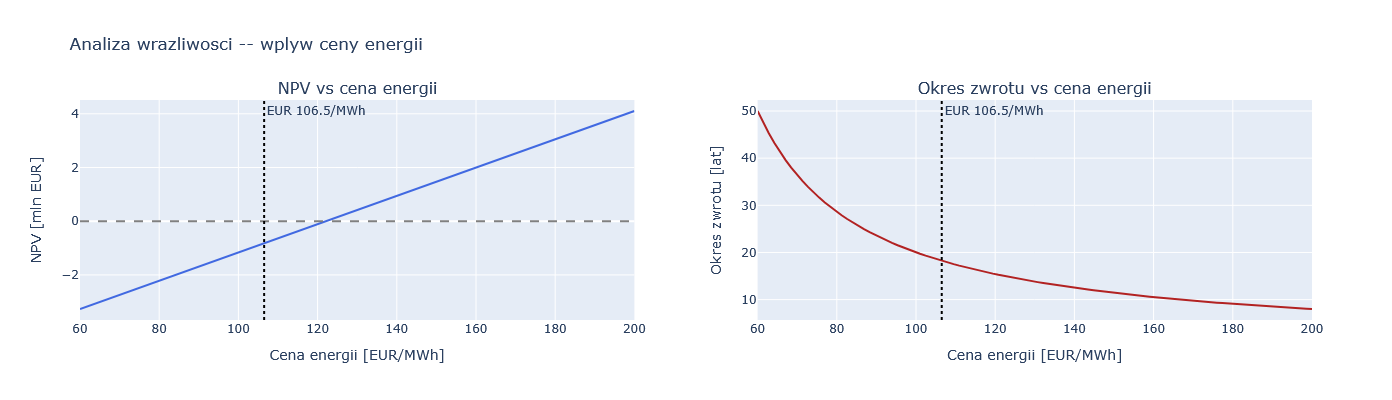

In [9]:
prices = np.linspace(60, 200, 100)
npvs = []
paybacks = []
for p in prices:
    e = economic_analysis(3500, inv['total_eur'], energy_price_eur_mwh=p)
    npvs.append(e['npv_eur'])
    paybacks.append(min(e['payback_years'], 50))

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['NPV vs cena energii', 'Okres zwrotu vs cena energii'])

fig.add_trace(go.Scatter(x=prices, y=[n/1e6 for n in npvs], mode='lines',
    line=dict(color='royalblue', width=2), name='NPV'), row=1, col=1)
fig.add_hline(y=0, line_color='gray', line_dash='dash', row=1, col=1)

fig.add_trace(go.Scatter(x=prices, y=paybacks, mode='lines',
    line=dict(color='firebrick', width=2), name='Payback'), row=1, col=2)

fig.add_vline(x=106.5, line_dash='dot', line_color='black',
    annotation_text='EUR 106.5/MWh')

fig.update_xaxes(title_text='Cena energii [EUR/MWh]')
fig.update_yaxes(title_text='NPV [mln EUR]', row=1, col=1)
fig.update_yaxes(title_text='Okres zwrotu [lat]', row=1, col=2)
fig.update_layout(height=400, showlegend=False,
    title='Analiza wrazliwosci -- wplyw ceny energii')
fig.show()

---
## Podsumowanie

| Model | Wzor / Zrodlo | Funkcja |
|-------|---------------|---------|
| Koszt EM | Ogayar & Vidal (2009) [1], inflacja 2009→2024 [6] | `electromechanical_cost()` |
| Roboty budowlane | Mnoznik × EM, IRENA (2012, 2023) [2,3] | `civil_works_cost()` |
| Przylacze | EUR/kW, NREL ATB (2024) [4] | `grid_connection_cost()` |
| Inzynieria | 10% sumy, IRENA (2012) [2] | `engineering_cost()` |
| O&M | 2.5%/rok, IRENA (2012) [2], IEA (2021) [5] | `annual_om_cost()` |
| Przychod | Cena × energia, URE 2024 [7] | `annual_revenue()` |
| NPV, LCOE, payback | Standardowe wzory finansowe | `economic_analysis()` |

### Zrodla

1. Ogayar B., Vidal P.G. (2009) *Renewable Energy* 34(1):6-13. [doi:10.1016/j.renene.2008.04.039](https://doi.org/10.1016/j.renene.2008.04.039)
2. IRENA (2012) *RE Technologies Cost Analysis — Hydropower.* [PDF](https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2012/RE_Technologies_Cost_Analysis-HYDROPOWER.pdf)
3. IRENA (2024) *Renewable Power Generation Costs in 2023.* [PDF](https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2024/Sep/IRENA_Renewable_power_generation_costs_in_2023.pdf)
4. NREL (2024) *ATB — Hydropower.* [Link](https://atb.nrel.gov/electricity/2024/hydropower)
5. IEA (2021) *Hydropower Special Market Report.* [PDF](https://iea.blob.core.windows.net/assets/83ff8935-62dd-4150-80a8-c5001b740e21/HydropowerSpecialMarketReport.pdf)
6. Eurostat HICP [prc_hicp_aind], EU-27, all items.
7. URE (2024) Urzad Regulacji Energetyki, srednia cena OZE.

**Dalej:** notebook 10 -- obliczenia produkcji (zlozenie wszystkich modeli)